# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [3]:
# untuk plot Q-Q
import scipy.stats as stats

In [4]:
df_california = pd.read_csv('california_dataset.csv')

In [5]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

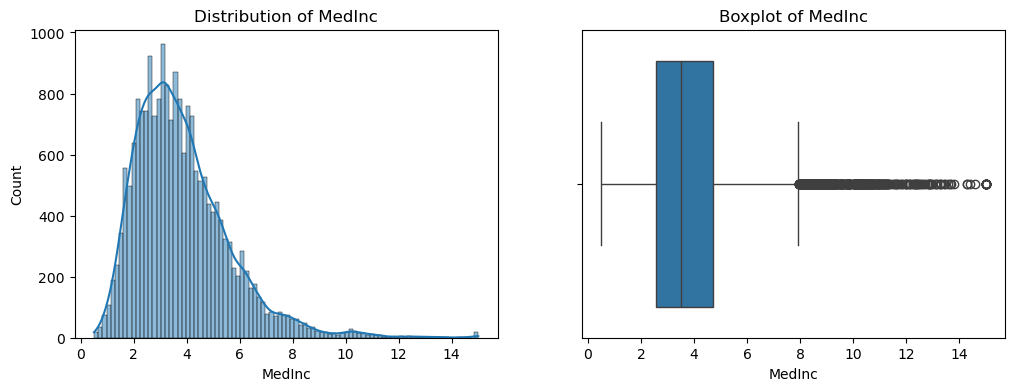

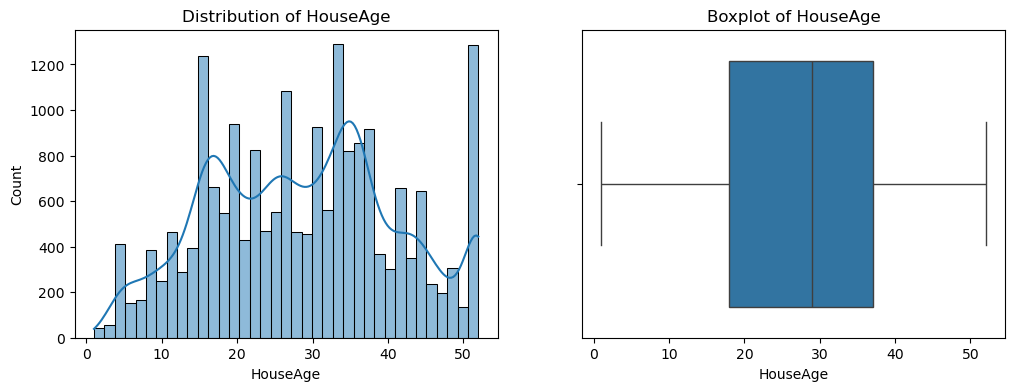

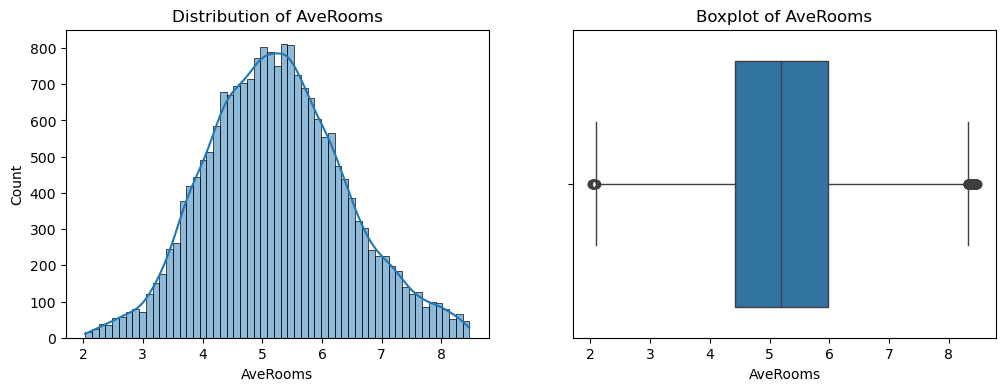

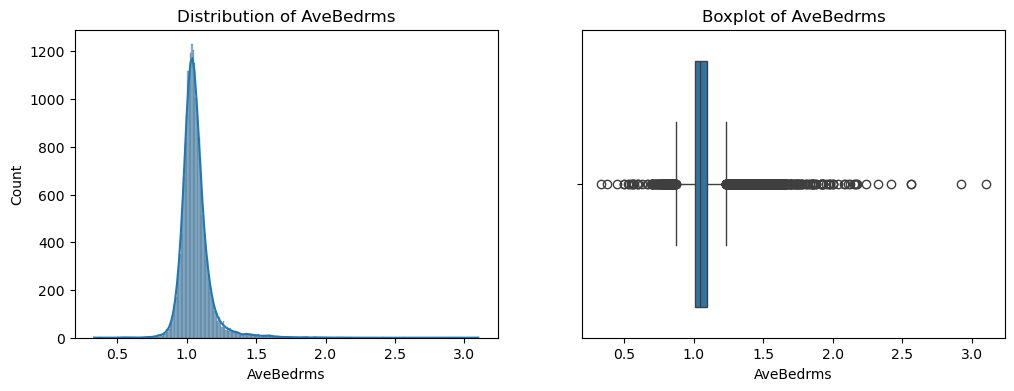

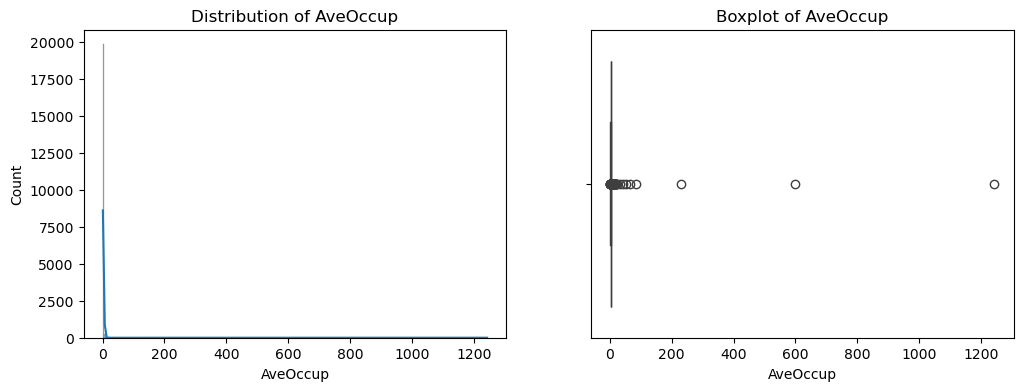

In [14]:
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for col in kolom_kolom:
    
    plt.figure(figsize=(12,4))
    
    # Histogram distribusi
    plt.subplot(1,2,1)
    sns.histplot(df_california[col], kde=True)
    plt.title(f'Distribution of {col}')
    
    # Boxplot outlier
    plt.subplot(1,2,2)
    sns.boxplot(x=df_california[col])
    plt.title(f'Boxplot of {col}')
    
    plt.show()

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [7]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

california = fetch_california_housing()

df_california = pd.DataFrame(california.data, columns=california.feature_names)

df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


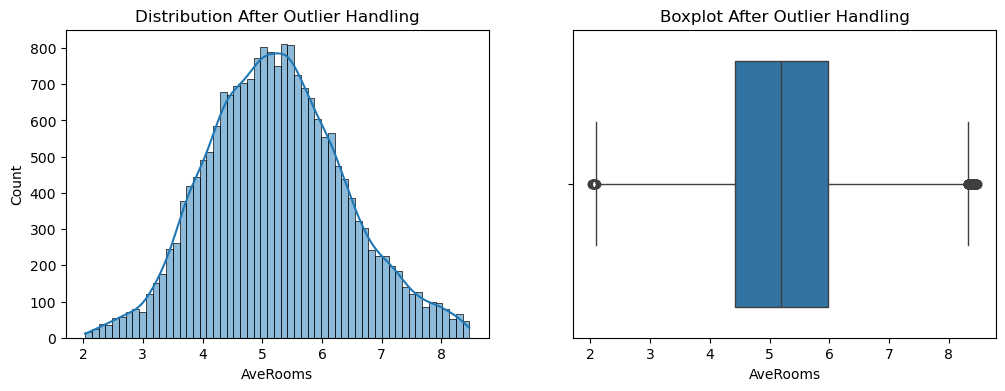

In [13]:
col = 'AveRooms'

Q1 = df_california[col].quantile(0.25)
Q3 = df_california[col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_california = df_california[(df_california[col] >= lower) & (df_california[col] <= upper)]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df_california[col], kde=True)
plt.title('Distribution After Outlier Handling')

plt.subplot(1,2,2)
sns.boxplot(x=df_california[col])
plt.title('Boxplot After Outlier Handling')

plt.show()

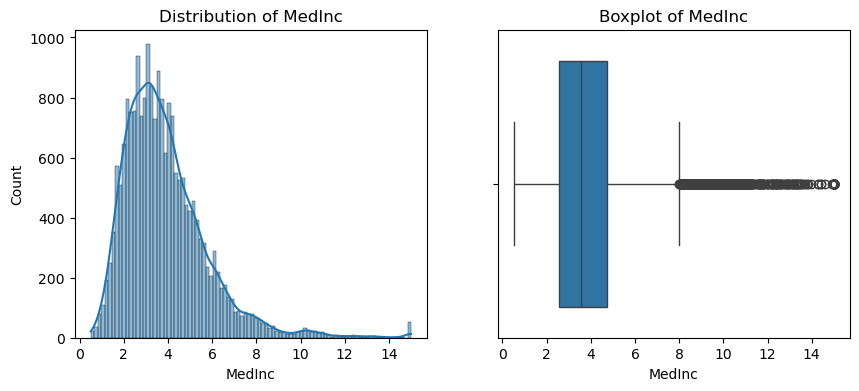

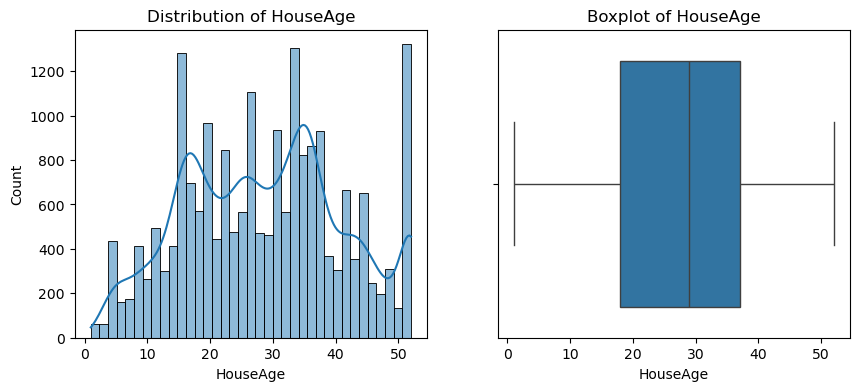

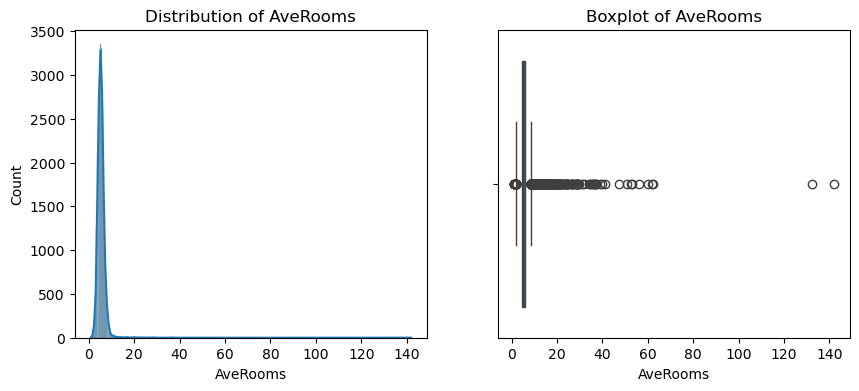

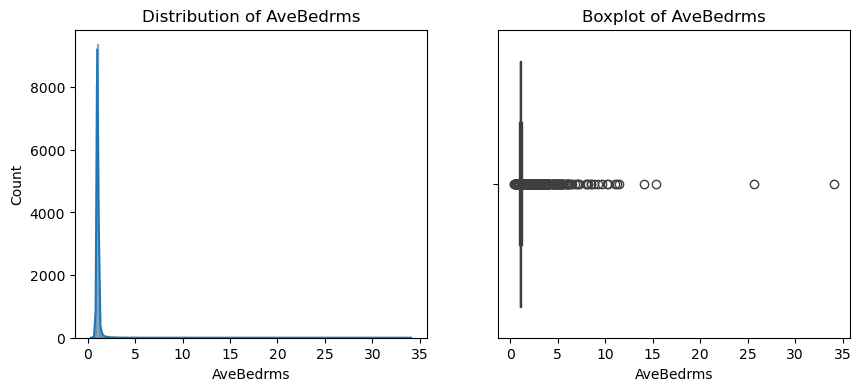

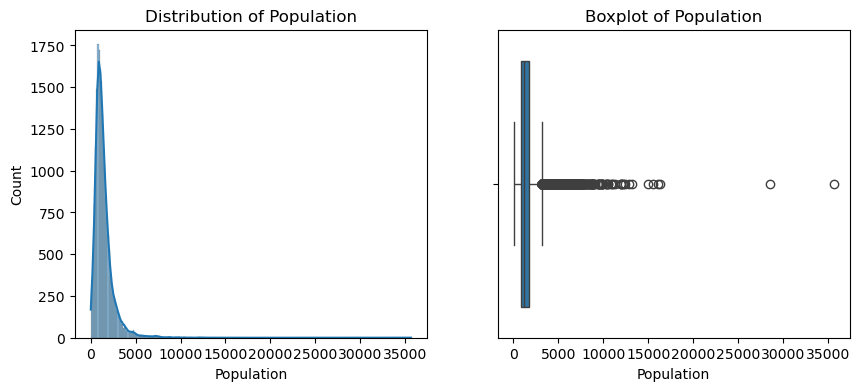

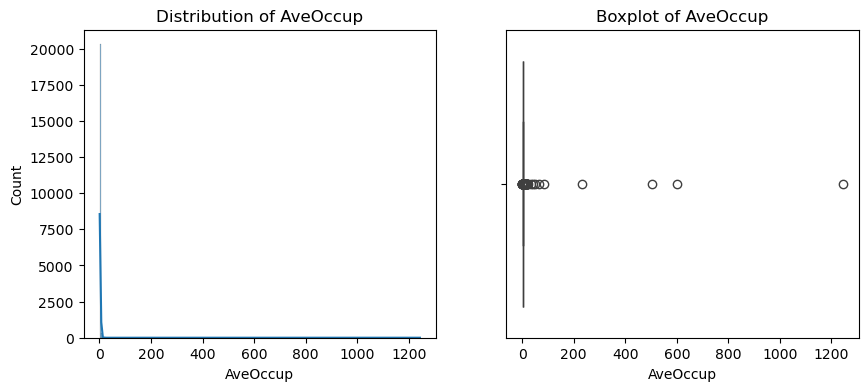

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

kolom_kolom = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup"]

for col in kolom_kolom:

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(df_california[col], kde=True)
    plt.title(f"Distribution of {col}")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_california[col])
    plt.title(f"Boxplot of {col}")

    plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [9]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [10]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [15]:
# cek missing value

missing_percentage = df_company['Headquarters'].isnull().mean() * 100
print("Missing Percentage :", missing_percentage)

# cek tipe missing value
print(df_company['Headquarters'].value_counts(dropna=False))

Missing Percentage : 0.0
Headquarters
New York, NY                 33
-1                           31
San Francisco, CA            31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, United Kingdom    10
Cambridge, MA                10
Vienna, VA                    8
Denver, CO                    7
Herndon, VA                   7
Washington, DC                7
Woodbine, MD                  7
Saint Louis, MO               7
Bedford, MA                   7
Arlington, VA                 7
San Jose, CA                  7
San Antonio, TX               6
Mountain View, CA             6
Basel, Switzerland            6
San Rafael, CA                6
Chantilly, VA                 6
Fairfax, VA                   5
Houston, TX                   5
Pittsburgh, PA                5
Bethesda, MD                  5
Rockville, MD                 5
Los Angeles, CA               5
Sp

In [17]:
mode_value = df_company['Headquarters'].mode()[0]

df_company['Headquarters'] = df_company['Headquarters'].fillna(mode_value)

print(df_company['Headquarters'].isnull().sum())

0


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [22]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [23]:
# Splitting terlebih dahulu

X = df_churn.drop('Churn', axis=1)
y = df_churn['Churn']

print(X.head())
print(y.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No        

## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [24]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder

columns = [
    'StreamingMovies',
    'StreamingTV',
    'TechSupport',
    'DeviceProtection',
    'OnlineBackup',
    'OnlineSecurity',
    'MultipleLines'
]


In [25]:
for col in columns:
    df_churn[col] = df_churn[col].replace('No internet service', 'No')
    
    # validasi dengan value_counts
    print(col)
    print(df_churn[col].value_counts())
    print()

StreamingMovies
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64

StreamingTV
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64

TechSupport
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64



In [26]:
le = LabelEncoder()

for col in columns:
    df_churn[col] = le.fit_transform(df_churn[col])

In [27]:
df_churn[columns].head()

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
0,0,0,0,0,1,0,1
1,0,0,0,1,0,1,0
2,0,0,0,0,1,1,0
3,0,0,1,1,0,1,1
4,0,0,0,0,0,0,0


## Selesai :)